In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 32 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > current_gw
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 25.22 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155449 entries, 0 to 155448
Columns: 454 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(449), object(5)
memory usage: 538.4+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 311 potential features:
Total rows: 43179

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                           tackles_elo_p90sq_3      37356    86.51            5823
                               tackles_p90sq_3      37356    86.51            5823
                        recoveries_elo_p90sq_3      37356    86.51            5823
                            recoveries_p90sq_3      37356    86.51            5823
                    defensive_cont_elo_p90sq_3      37356    86.51            5823
                        defensive_cont_p90sq_3      37356    86.51            5823
                               cbi_elo_p90sq_3      37356    86.51            5823
                                   cbi_p90sq_3      37356    86.51            5823
                        recoveries_elo_p90sq_5      37304    86.39            5875
                            recoveries_p90sq_5      37304    86

In [5]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [6]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [7]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [8]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [9]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [10]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2675/8012

Training Set Performance:
R² Score: 0.8199
RMSE: 13.9153
MAE: 11.4850

Test Set Performance:
R² Score: 0.3861
RMSE: 25.5043
MAE: 20.7647

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.327069
           minutes_elo_3    0.029642
    opp_team_elo_p90sq_3    0.015753
        team_elo_p90sq_5    0.013052
    opp_team_elo_p90sq_5    0.012890
       team_elo_p90sq_10    0.010920
   opp_team_elo_p90sq_at    0.009446
   opp_team_elo_p90sq_10    0.008777
 opp_team_elo_elo_p90_10    0.008670
            opp_team_elo    0.008643
   clean_sheets_p90sq_at    0.007996
       team_elo_p90sq_at    0.007909
                elo_diff    0.007844
opp_team_elo_elo_p90sq_5    0.007385
         xg_over_g_ratio    0.007342
                 assists    0.007279
          opp_team_elo_5    0.007207
                 fixture    0.007031
 goals_conceded_p90sq_at    0.006842
          opp_team_elo_3    0.006431
Cleaned df size: 9229/29840



In [11]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2777/4610

Training Set Performance:
R² Score: 0.6313
RMSE: 0.2352
MAE: 0.1889

Test Set Performance:
R² Score: 0.0399
RMSE: 0.3853
MAE: 0.2915

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.049386
    goals_scored_p90sq_at    0.036383
                  fixture    0.032877
          xg_over_g_ratio    0.024795
             opp_team_elo    0.021129
          opp_team_elo_10    0.018465
         assists_p90sq_at    0.017298
           bonus_p90sq_at    0.016308
           opp_team_elo_5    0.015558
           opp_team_elo_3    0.015341
         team_elo_p90sq_5    0.012850
         team_elo_p90sq_3    0.012230
     minutes_elo_p90sq_10    0.011787
             bps_p90sq_at    0.011381
               assists_at    0.010255
total_points_elo_p90sq_10    0.010064
        team_elo_p90sq_at    0.009685
     opp_team_elo_p90sq_5    0.009596
    total_points_p90sq_10    0.009099
  go

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2981/4911

Training Set Performance:
R² Score: 0.6473
RMSE: 0.0691
MAE: 0.0477

Test Set Performance:
R² Score: 0.0410
RMSE: 0.1296
MAE: 0.0737

Top 20 Feature Importances:
                feature  importance
                assists    0.115846
                fixture    0.040979
         opp_team_elo_3    0.037712
         assists_elo_10    0.032291
   goals_conceded_elo_3    0.024258
           opp_team_elo    0.016689
               elo_diff    0.015052
        xg_over_g_ratio    0.010534
goals_conceded_p90sq_at    0.010125
        opp_team_elo_10    0.009548
  goals_conceded_elo_10    0.009321
          minutes_elo_3    0.009283
  total_points_p90sq_at    0.009233
         opp_team_elo_5    0.008928
     minutes_elo_p90_10    0.008817
         bonus_p90sq_at    0.008739
   total_points_p90sq_3    0.008576
      minutes_elo_p90_5    0.008051
             bps_elo_10    0.007944
       goals_conceded_3    0.007929
target

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2981/4911

Training Set Performance:
R² Score: 0.6894
RMSE: 0.5171
MAE: 0.4206

Test Set Performance:
R² Score: 0.2500
RMSE: 0.7749
MAE: 0.5951

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.166702
                fixture    0.055586
        xg_over_g_ratio    0.034935
           opp_team_elo    0.028895
        opp_team_elo_10    0.019219
         opp_team_elo_5    0.017703
goals_conceded_p90sq_at    0.012696
  clean_sheets_p90sq_at    0.012669
         assists_p90_at    0.011405
         opp_team_elo_3    0.011187
       assists_p90sq_at    0.008607
             assists_at    0.008404
     minutes_elo_p90_10    0.008247
  goals_scored_p90sq_at    0.008144
  total_points_p90sq_at    0.008017
      team_elo_p90sq_at    0.007923
         bonus_p90sq_at    0.007841
        bps_elo_p90sq_5    0.007722
               team_elo    0.007425
  goals_conceded_elo_10    0.00686

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4393/4911

Training Set Performance:
R² Score: 0.5094
RMSE: 13.0812
MAE: 10.4616

Test Set Performance:
R² Score: 0.0873
RMSE: 16.7091
MAE: 12.8033

Top 20 Feature Importances:
                  feature  importance
                  assists    0.170433
                 elo_diff    0.056739
             opp_team_elo    0.024286
          opp_team_elo_10    0.016499
                  fixture    0.013823
  goals_conceded_p90sq_at    0.013793
           opp_team_elo_3    0.013534
     minutes_elo_p90sq_10    0.011761
           opp_team_elo_5    0.011622
clean_sheets_elo_p90sq_10    0.010240
         assists_p90sq_at    0.010148
      minutes_elo_p90sq_3    0.009529
           bonus_p90sq_at    0.008721
    opp_team_elo_p90sq_at    0.007884
             bps_p90sq_at    0.007731
     goals_conceded_elo_3    0.007546
          xg_over_g_ratio    0.007267
    opp_team_elo_p90sq_10    0.007157
              bps_p90sq_5    0.007062
    total_

In [15]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 4119/4392

Training Set Performance:
R² Score: 0.5618
RMSE: 1.3024
MAE: 1.0594

Test Set Performance:
R² Score: 0.0688
RMSE: 1.8154
MAE: 1.3869

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.128260
               opp_team_elo    0.024991
                    fixture    0.017986
      opp_team_elo_p90sq_at    0.016638
             saves_p90sq_at    0.016366
               bps_p90sq_at    0.015954
    goals_conceded_p90sq_at    0.014479
          team_elo_p90sq_at    0.014298
          saves_elo_p90sq_5    0.014213
            opp_team_elo_10    0.012478
             opp_team_elo_5    0.012160
         saves_elo_p90sq_10    0.011883
             saves_p90sq_10    0.011593
      clean_sheets_p90sq_at    0.011361
      total_points_p90sq_at    0.010970
      total_points_p90sq_10    0.010107
             bonus_p90sq_at    0.010105
             opp_team_elo_3    0.010082
goals_conce

In [16]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 698/5422

Training Set Performance:
R² Score: 0.8075
RMSE: 1.2681
MAE: 1.0171

Test Set Performance:
R² Score: -0.0121
RMSE: 2.9322
MAE: 2.2147

Top 20 Feature Importances:
                feature  importance
goals_conceded_p90sq_at    0.031950
  clean_sheets_p90sq_at    0.028359
             minutes_10    0.026857
        xg_over_g_ratio    0.023507
                fixture    0.021598
             assists_at    0.020276
  opp_team_elo_p90sq_at    0.018462
        opp_team_elo_10    0.017380
         opp_team_elo_5    0.016925
         opp_team_elo_3    0.016624
         bonus_p90sq_at    0.013766
               team_elo    0.013324
           opp_team_elo    0.013272
   goals_conceded_elo_3    0.013164
              minutes_5    0.012821
            bps_p90sq_5    0.012113
       assists_p90sq_at    0.011282
                  bps_3    0.011217
   goals_conceded_elo_5    0.011080
   goals_conceded_p90_3    0.010

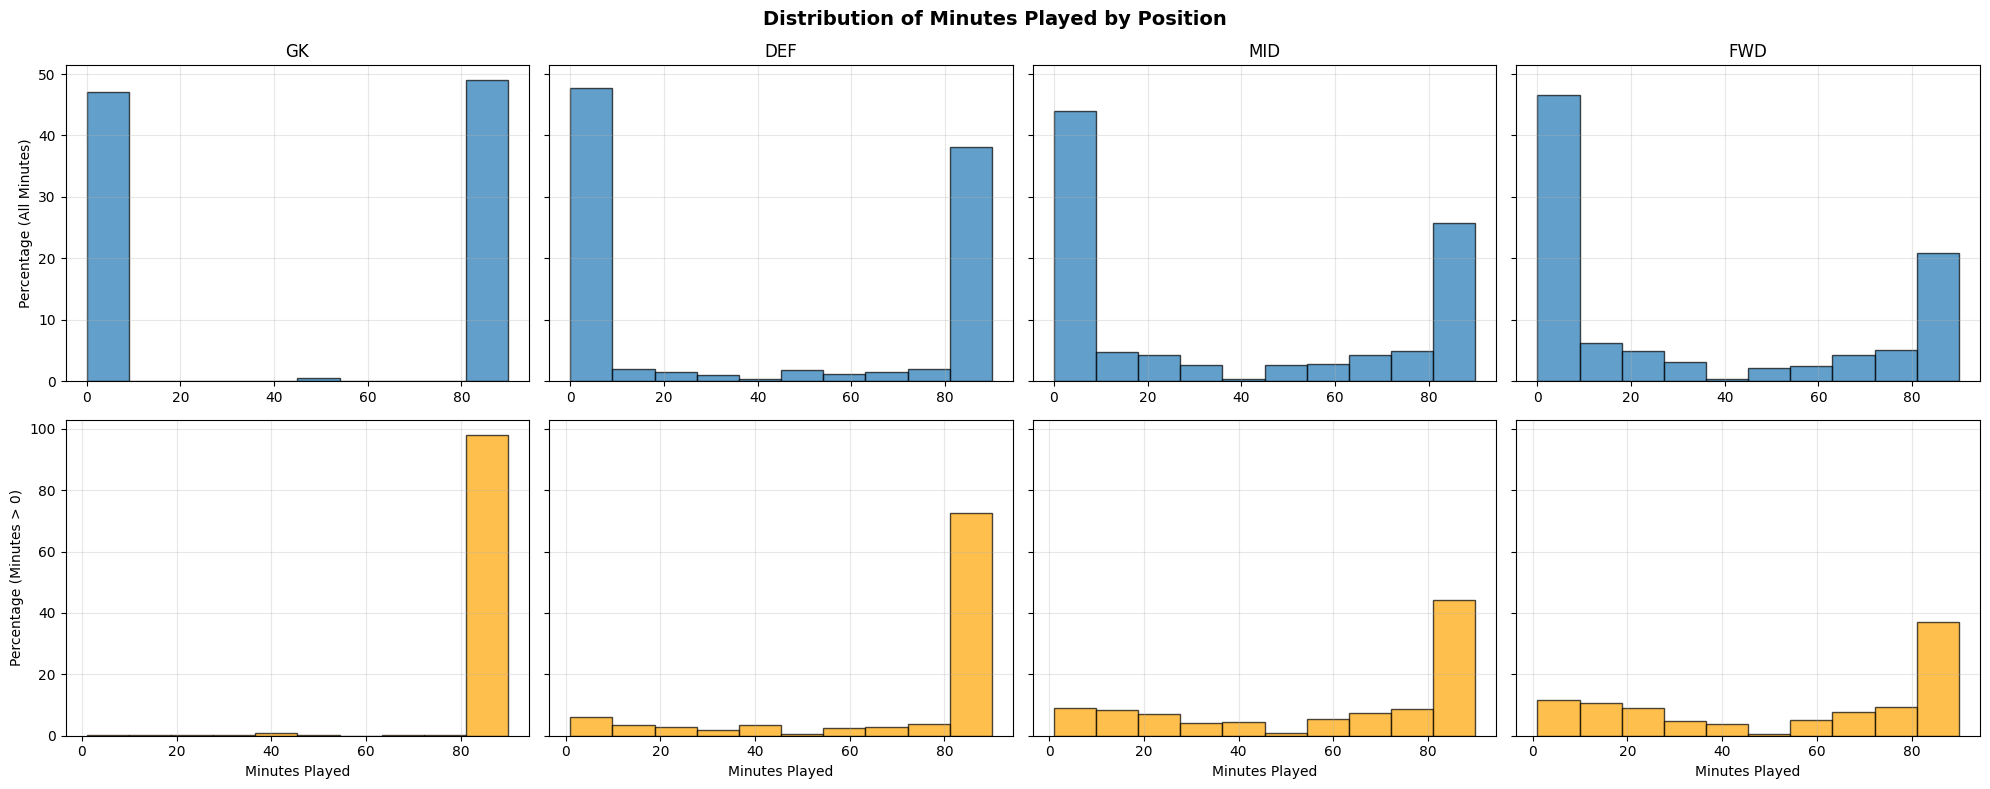

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.365


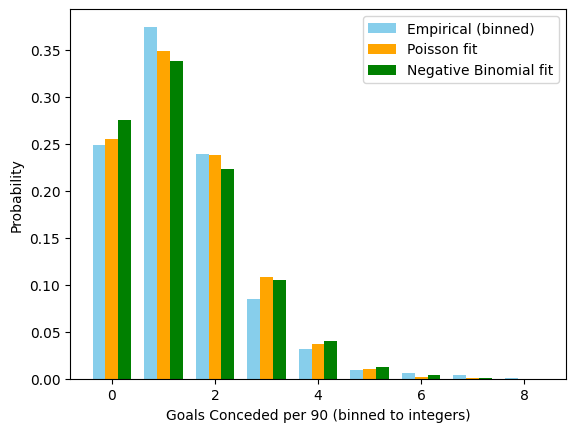

Mean: 1.356, Variance: 1.496
Overdispersion ratio (Var/Mean): 1.104
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.255


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.234


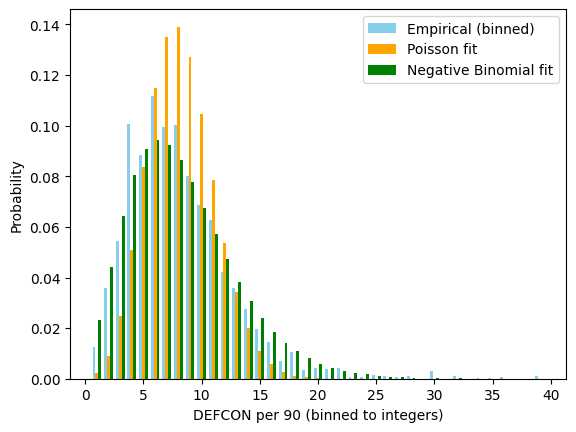

Mean: 8.226, Variance: 21.397
Overdispersion ratio (Var/Mean): 2.601
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [19]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.199


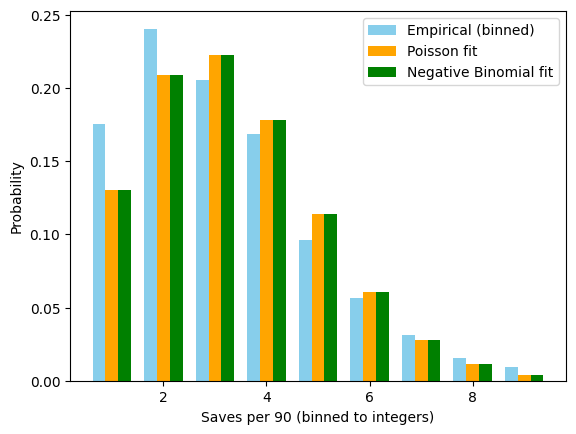

Mean: 3.199, Variance: 3.203
Overdispersion ratio (Var/Mean): 1.001
✅ Poisson assumption looks reasonable.


In [20]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [21]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [22]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [23]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    3138.000000
mean       59.563104
std        20.638652
min        11.540605
25%        41.769035
50%        60.662711
75%        79.431213
max        89.899589
Name: mins_pred, dtype: float64

In [24]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    2922.000000
mean        0.176976
std         0.141480
min         0.034890
25%         0.061669
50%         0.132846
75%         0.259037
max         0.744154
Name: xgp90_pred, dtype: float64

In [25]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    2922.000000
mean        0.088883
std         0.063714
min         0.021446
25%         0.047257
50%         0.072740
75%         0.114263
max         0.448964
Name: xap90_pred, dtype: float64

In [26]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    3138.000000
mean        1.567193
std         0.358401
min         0.407431
25%         1.361750
50%         1.513605
75%         1.745594
max         2.682851
Name: xgcp90_pred, dtype: float64

In [27]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    3138.000000
mean       14.347340
std         2.950100
min         4.340103
25%        12.309359
50%        13.928911
75%        16.202049
max        28.572866
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.684e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                        0.00
Time:                        11:50:17   Log-Likelihood:                         -42949.
No. Observations:               45549   AIC:                                  8.590e+04
Df Residuals:                   45548   BIC:                                  8.591e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

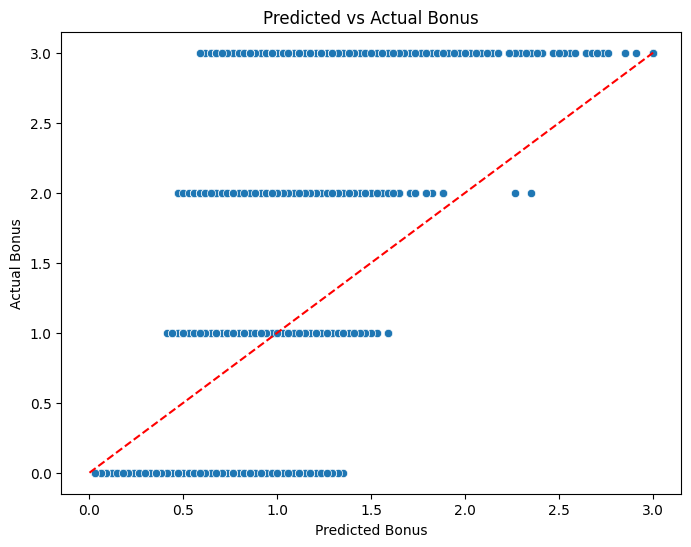

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459394  0.228520  1.107189  1.946092
FWD           0.331307  0.198321  1.047554  1.711821
GK            0.488634  0.244957  1.113043  2.008160
GKP                NaN       NaN       NaN       NaN
MID           0.397020  0.244720  1.050677  1.827099


C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [28]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [29]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [30]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    216.000000
mean       3.259264
std        0.678077
min        1.288587
25%        2.794362
50%        3.160626
75%        3.662538
max        5.173200
Name: xsavesp90_pred, dtype: float64

In [31]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    2922.000000
mean        8.059554
std         1.844500
min         3.231482
25%         6.821652
50%         8.091399
75%         9.429284
max        18.763253
Name: xdefconp90_pred, dtype: float64

In [32]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135655,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,33.0,West Ham,996.205478,63.599306,0.073366,0.105184,1.225511
135657,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,34.0,Liverpool,1158.609756,64.654684,0.071655,0.100962,1.518506
135659,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,35.0,Bournemouth,1083.144286,64.654684,0.073776,0.104349,1.430058
135661,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Everton,1075.115184,64.654684,0.073776,0.108717,1.451131
135663,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,37.0,Brentford,1073.538381,64.032831,0.073776,0.108717,1.460923


In [33]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
140075,Dominic Calvert-Lewin,691.0,56.0,Leeds,FWD,20252026.0,33.0,Wolves,937.067560,74.744465,0.744154,0.042041,1.165745
147149,Lorenzo Lucca,805.0,55.0,Nott'm Forest,FWD,20252026.0,33.0,Burnley,880.681360,44.326858,0.674051,0.192182,1.423608
138549,Charalampos Kostoulas,181.0,48.0,Brighton,FWD,20252026.0,33.0,Spurs,950.790451,32.403660,0.659003,0.157071,1.381065
145815,Justin Kluivert,81.0,69.0,Bournemouth,MID,20252026.0,33.0,Newcastle,1067.382336,51.699641,0.648297,0.112383,2.093164
144988,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,33.0,Brentford,1073.538381,34.009157,0.647870,0.132589,1.614362
145817,Justin Kluivert,81.0,69.0,Bournemouth,MID,20252026.0,33.0,Leeds,997.877011,51.779747,0.638894,0.103731,2.559942
147596,Marc Guiu Paz,252.0,40.0,Chelsea,FWD,20252026.0,33.0,Man Utd,1098.438261,44.010127,0.618812,0.135719,1.563801
147598,Marc Guiu Paz,252.0,40.0,Chelsea,FWD,20252026.0,33.0,Brighton,1097.373304,44.060127,0.616666,0.134921,1.591253
148109,Mason Mount,455.0,59.0,Man Utd,MID,20252026.0,33.0,Chelsea,1106.027227,21.034614,0.584711,0.153490,1.645290
140076,Dominic Calvert-Lewin,691.0,56.0,Leeds,FWD,20252026.0,33.0,Bournemouth,1083.144286,75.654698,0.574962,0.040498,1.157010


In [34]:
# -----------------------------------------------------------------------
# Build per-player overperformance factors from ALL historical data in df
# -----------------------------------------------------------------------
# stat_pairs: (actual_column, expected_column, output_key)
#   'xg' key  → will be applied to xgp90_pred
#   'xa' key  → will be applied to xap90_pred

from FPLStatOverperformanceAnalyzer import (
    FPLStatOverperformanceAnalyzer,
    build_player_adjustments,
    apply_adjustments,
)

overperf_adjustments = build_player_adjustments(
    df,
    stat_pairs=[
        ('goals_scored',  'expected_goals',   'xg'),
        ('assists',       'expected_assists',  'xa'),
    ],
    prior_weight=0.3,           # 30% prior, 70% observed
    only_if_significant=True,   # only adjust if p < 0.05
    min_xstat=2.0,    # need ≥2 cumulative xG/xA to run test
    min_games=5,                # need ≥5 appearances
)

print(f"Computed adjustments for {len(overperf_adjustments)} players")

# Apply factors to prediction_data
#   - Saves original columns as xgp90_pred_raw / xap90_pred_raw
#   - Adds xg_overperf_factor / xa_overperf_factor columns for audit
prediction_data = apply_adjustments(
    prediction_data,
    overperf_adjustments,
    col_map={
        'xg': 'xgp90_pred',
        'xa': 'xap90_pred',
    },
)

# Show the adjustment for the next gameweek's top players
print(f"\nNext GW{current_gw + 1} Top Players with Overperformance Factors:")
(
    prediction_data[prediction_data['event'] == current_gw + 1]
    [['player_name_id','position', 'xg_overperf_factor', 'xa_overperf_factor',
      'xgp90_pred_raw', 'xgp90_pred',
      'xap90_pred_raw', 'xap90_pred']].groupby('player_name_id').agg({'position': 'first', 'xg_overperf_factor': 'mean', 'xa_overperf_factor': 'mean',
                                                                      'xgp90_pred_raw': 'mean', 'xgp90_pred': 'mean', 'xap90_pred_raw': 'mean', 'xap90_pred': 'mean'})
    .sort_values('xg_overperf_factor', ascending=False)
    .head(30))

Computed adjustments for 2611 players

Next GW33 Top Players with Overperformance Factors:


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[f"{col}_raw"]             = prediction_data[col].copy()
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[col]                      = prediction_data[col] * factors
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOver

,position,xg_overperf_factor,xa_overperf_factor,xgp90_pred_raw,xgp90_pred,xap90_pred_raw,xap90_pred
player_name_id,,,,,,,
Reece James,DEF,3.529676,2.578782,0.067665,0.238836,0.152615,0.393560
Mason Mount,MID,3.345491,4.482544,0.584711,1.956147,0.153490,0.688026
John Stones,DEF,3.159828,1.000000,0.252420,0.797602,0.068896,0.068896
Michael Keane,DEF,2.512190,1.000000,0.065041,0.163396,0.031298,0.031298
Youri Tielemans,MID,2.326342,2.017140,0.101400,0.235892,0.136923,0.276192
Conor Gallagher,MID,2.197247,2.872158,0.118701,0.260815,0.058119,0.166927
Phil Foden,MID,2.174519,1.578157,0.213678,0.464646,0.145289,0.229289
James Ward-Prowse,MID,2.172516,1.596224,0.126375,0.274551,0.133399,0.212935
Ryan Sessegnon,MID,2.126722,2.243065,0.133847,0.284655,0.073890,0.165741


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_1456\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xg_overperf_factor', 'xa_overperf_factor','xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xg_overperf_factor=('xg_overperf_factor', 'mean'),
    xa_overperf_factor=('xa_overperf_factor', 'mean'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xg_overperf_factor,xa_overperf_factor,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [39]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [40]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          2983 non-null   object 
 1   element                 2983 non-null   float64
 2   season                  2983 non-null   float64
 3   event                   2983 non-null   float64
 4   team_name               2983 non-null   object 
 5   team_elo                2983 non-null   float64
 6   opp_team_name           2983 non-null   object 
 7   opp_team_elo            2983 non-null   float64
 8   position                2983 non-null   object 
 9   value                   2983 non-null   float64
 10  fixture_count           2983 non-null   float64
 11  mins_pred               2983 non-null   float64
 12  xpoints                 2983 non-null   float64
 13  xpoints_mins            2983 non-null   float64
 14  xpoints_goals           2983 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, fixture_count, opp_team_name, opp_team_elo
                            FROM predictions
                        WHERE season = 20252026 
                          AND event = 33
                          AND player_name_id = 'Cole Palmer'
                            """)
view

,player_name_id,team_name,team_elo,season,event,fixture_count,opp_team_name,opp_team_elo
0,Cole Palmer,Chelsea,1106.027227,20252026.0,33.0,2.0,Man Utd; Brighton,1097.905783


In [44]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 33 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
244,John Stones,409.0,33.0,54.0,Man City,DEF,13.343035
265,Joško Gvardiol,403.0,33.0,59.0,Man City,DEF,11.763299
55,Bernardo Mota Veiga de Carvalho e Silva,416.0,33.0,62.0,Man City,MID,11.409083
32,Antoine Semenyo,82.0,33.0,82.0,Man City,MID,11.346016
336,Matheus Nunes,407.0,33.0,53.0,Man City,DEF,11.206146
382,Nico O'Reilly,411.0,33.0,50.0,Man City,DEF,10.589679
139,Erling Haaland,430.0,33.0,144.0,Man City,FWD,10.077303
323,Marc Guéhi,260.0,33.0,51.0,Man City,DEF,9.970913
340,Mats Wieffer,173.0,33.0,49.0,Brighton,MID,9.951311
118,Dominic Calvert-Lewin,691.0,33.0,56.0,Leeds,FWD,9.938662


In [45]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW33 - GW37


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
244,John Stones,290.982945,7.275454,15.087082,0.624119,5.191173,0.0,-2.307971,2.716790,2.594034,31.180681
199,Jack Grealish,272.070329,6.819435,10.734539,8.049247,0.697425,0.0,0.000000,2.557028,2.207753,31.065427
55,Bernardo Mota Veiga de Carvalho e Silva,400.366719,9.404587,3.440776,9.283054,1.612427,0.0,0.000000,2.557028,2.550323,28.848195
48,Ben Davies,275.131994,6.894338,5.377442,11.893765,3.380175,0.0,-3.313556,2.716790,1.696513,28.645466
68,Bukayo Saka,385.951724,9.239966,7.553571,3.957473,2.156209,0.0,0.000000,2.557028,2.620990,28.085237
32,Antoine Semenyo,411.169800,9.511062,8.801164,3.192945,1.563228,0.0,0.000000,2.557028,2.344992,27.970419
265,Joško Gvardiol,298.732014,7.468295,7.020831,4.077703,5.823407,0.0,-2.044360,2.716790,2.742816,27.805481
163,Gabriel dos Santos Magalhães,416.425631,9.555359,2.022931,1.973788,9.147914,0.0,-1.082881,2.716790,2.917226,27.251126
66,Bruno Guimarães Rodriguez Moura,299.597455,7.489937,9.075677,3.949889,0.937853,0.0,0.000000,2.557028,2.724870,26.735254
336,Matheus Nunes,431.808024,9.665502,1.378150,4.438414,7.212967,0.0,-1.595376,2.716790,2.763449,26.579895


In [46]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
199,Jack Grealish,325.665864,8.164581,12.807682,9.636727,0.777666,0.0,0.000000,3.068433,2.704664,37.159753
244,John Stones,348.552725,8.714996,18.175359,0.748291,5.813786,0.0,-2.994068,3.260148,3.128783,36.847294
48,Ben Davies,331.909166,8.314457,6.503983,14.344156,3.911684,0.0,-4.077088,3.260148,2.022956,34.280295
55,Bernardo Mota Veiga de Carvalho e Silva,478.557535,11.265043,4.141676,10.758005,1.843746,0.0,0.000000,3.068433,3.018072,34.094976
68,Bukayo Saka,462.902759,11.084861,9.465214,4.796514,2.495806,0.0,0.000000,3.068433,3.152286,34.063114
32,Antoine Semenyo,492.438652,11.404551,10.599387,3.757140,1.779058,0.0,0.000000,3.068433,2.782733,33.391303
265,Joško Gvardiol,357.899867,8.947503,8.422342,4.887359,6.538594,0.0,-2.663094,3.260148,3.306908,32.699760
163,Gabriel dos Santos Magalhães,499.863456,11.467797,2.415850,2.385024,10.698211,0.0,-1.344358,3.260148,3.545110,32.427781
225,Jarrod Bowen,480.651748,11.291071,11.477770,5.126723,0.000000,0.0,0.000000,1.610029,2.790762,32.296355
66,Bruno Guimarães Rodriguez Moura,359.518819,8.987971,10.885636,4.729695,1.119148,0.0,0.000000,3.068433,3.318621,32.109505


In [47]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [48]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [51]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists, p.xg_overperf_factor,p.xa_overperf_factor,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [52]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 2983 new predictions to predictions_allgws


In [53]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points
122325,Erling Haaland,20252026.0,33.0,NaN,NaN
122326,Erling Haaland,20252026.0,33.0,NaN,NaN
122327,Erling Haaland,20252026.0,33.0,NaN,NaN
122328,Erling Haaland,20252026.0,33.0,NaN,NaN
125599,Erling Haaland,20252026.0,33.0,327.0,NaN


In [54]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=25)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
191661,Erling Haaland,25.0,20252026.0,11.0,90.0
191662,Erling Haaland,26.0,20252026.0,5.0,45.0
191663,Erling Haaland,27.0,20252026.0,6.0,90.0
191664,Erling Haaland,28.0,20252026.0,0.0,0.0
191665,Erling Haaland,29.0,20252026.0,2.0,90.0
191666,Erling Haaland,30.0,20252026.0,2.0,90.0
191667,Erling Haaland,32.0,20252026.0,2.0,90.0
205412,Erling Haaland,33.0,20252026.0,NaN,NaN
205416,Erling Haaland,33.0,20252026.0,NaN,NaN
205417,Erling Haaland,35.0,20252026.0,NaN,NaN


In [55]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
...,...,...,...,...,...
119451,Erling Haaland,2026-04-09 16:15:18.991612,38.0,4.204206,NaN
19374,Erling Haaland,2026-01-27 11:00:04.422834,38.0,3.494566,NaN
122871,Erling Haaland,2026-04-11 19:52:12.859110,38.0,4.091495,NaN
125601,Erling Haaland,2026-04-12 12:24:18.382275,38.0,4.267749,NaN


In [56]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
                                                          35.0   3.388855
                                                          36.0   3.436291
...                                                                   ...
2026-04-14 11:50:26.074493 32                  20252026.0 33.0   5.018246
                                                          34.0   3.416212
                                                          35.0   3.418686
                                                          36.0   3.354637
                                                          37.0   3.403960

[181 rows x 1 columns]

In [57]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [ ]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==20252026) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,fixture,xpoints,total_points
13473,2026-01-05 18:33:33.065519,20,20252026.0,33.0,NaN,4.478146,NaN
5668,2026-01-26 14:27:00.627006,23,20252026.0,33.0,NaN,3.542623,NaN
19370,2026-01-27 11:00:04.422834,23,20252026.0,33.0,NaN,3.475960,NaN
26616,2026-02-01 11:57:12.353330,24,20252026.0,33.0,NaN,3.204079,NaN
33633,2026-02-02 13:38:00.840050,24,20252026.0,33.0,NaN,3.755389,NaN
40650,2026-02-03 14:41:19.430154,24,20252026.0,33.0,NaN,4.027643,NaN
47464,2026-02-09 12:29:03.939012,25,20252026.0,33.0,NaN,4.547072,NaN
53798,2026-02-13 13:00:38.658664,26,20252026.0,33.0,NaN,4.492147,NaN
59828,2026-02-19 17:56:20.307174,26,20252026.0,33.0,NaN,4.373983,NaN
65859,2026-02-20 10:52:25.776847,26,20252026.0,33.0,NaN,4.386840,NaN


In [59]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,34.500000
min,2026-01-07 16:29:20.849190,32.000000
25%,2026-01-07 16:29:20.849189888,33.000000
50%,2026-01-08 04:37:05.395073024,34.500000
75%,2026-01-08 16:44:49.940955904,36.000000
max,2026-01-08 16:44:49.940956,37.000000
std,NaN,1.744557


In [60]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [61]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 33.17 minute(s)

Finished in 57.02 minute(s)


In [62]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)